In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("customer_dataset.csv")
df.head()


,customer_id,total_spend,avg_order_value,purchase_frequency,recency,customer_age,churn
0,1,6277.85,627.785000,10,30,210,0
1,2,10502.12,1166.902222,9,28,852,0
2,3,8467.02,604.787143,14,19,540,0
3,4,5467.84,607.537778,9,18,57,0
4,5,8104.03,810.403000,10,51,524,0


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1000 non-null   int64  
 1   total_spend         1000 non-null   float64
 2   avg_order_value     1000 non-null   float64
 3   purchase_frequency  1000 non-null   int64  
 4   recency             1000 non-null   int64  
 5   customer_age        1000 non-null   int64  
 6   churn               1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB


customer_id           0
total_spend           0
avg_order_value       0
purchase_frequency    0
recency               0
customer_age          0
churn                 0
dtype: int64

In [5]:
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.995

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       142
           1       1.00      0.98      0.99        58

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



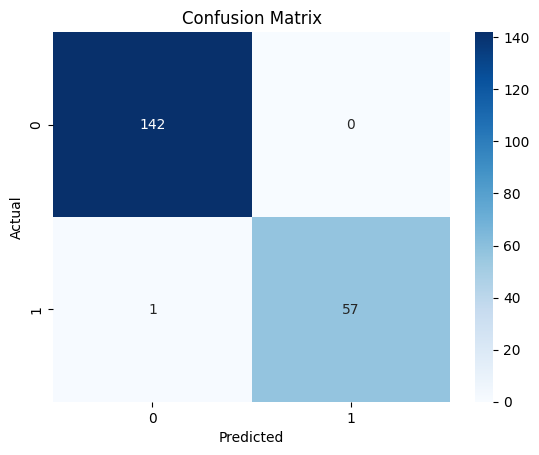

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

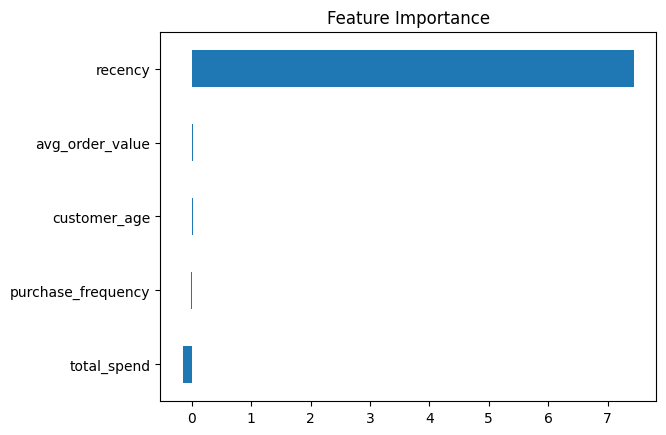

In [12]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [14]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [16]:
print("🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))

print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

🔹 Logistic Regression
Accuracy: 0.995
Precision: 1.0
Recall: 0.9827586206896551

🔹 Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0


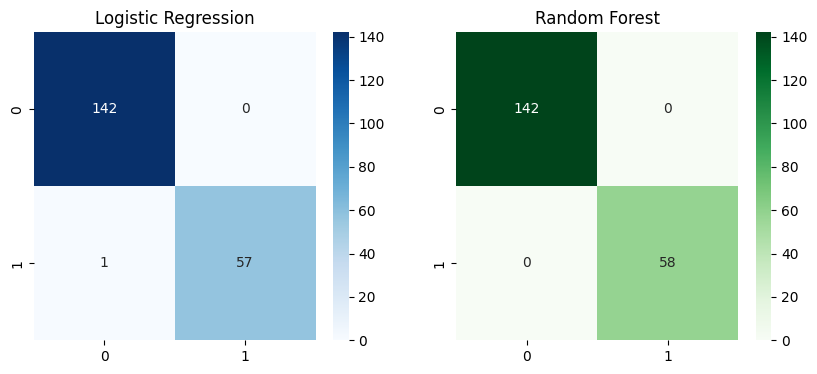

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression")

plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest")

plt.show()

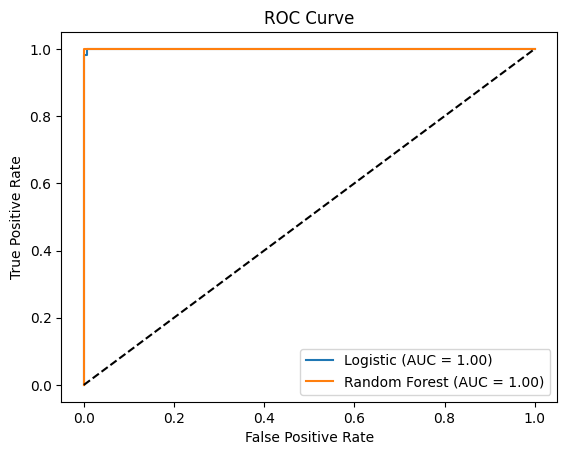

In [18]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.995,1.0,0.982759
1,Random Forest,1.000,1.0,1.000000


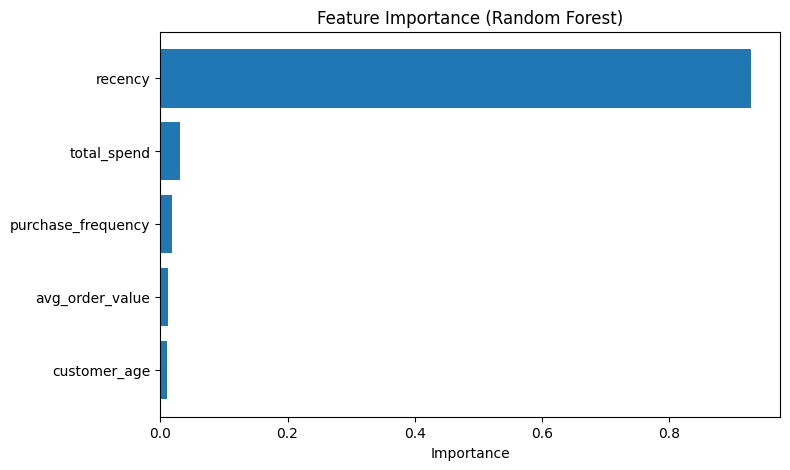

,feature,importance
3,recency,0.927693
0,total_spend,0.031316
2,purchase_frequency,0.018033
1,avg_order_value,0.012302
4,customer_age,0.010657


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

importance_df

In [21]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
3,recency,7.438862
1,avg_order_value,0.029877
4,customer_age,0.017929
2,purchase_frequency,-0.009435
0,total_spend,-0.150432


In [22]:
import joblib

joblib.dump(log_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [23]:
mv ml/churn_model.pkl .
mv ml/scaler.pkl .

SyntaxError: invalid syntax (2405818860.py, line 1)